## **Clusterização de Incidentes**

Clusterização perfil do incidente na abertura (informações existentes antes do fechamento do incidente)

Essa clusterização teve o objetivo de mostrar que existem três comportamentos operacionais completamente diferentes dentro da operação de TI, e cada um exige uma estratégia específica.

| Cluster   | Perfil                                            |
| --------- | ------------------------------------------------- |
| Cluster 0 | Eventos gerados automaticamente por monitoramento |
| Cluster 1 | Incidentes operacionais do dia a dia              |
| Cluster 2 | Incidentes especializados e mais críticos         |


### Cluster 0: Monitoramento Massivo
- Representa 63% da base (77.719 chamados)
- 100% originado por monitoramento
- 71% prioridade baixa

Possíveis problemas para a empresa:
- Alert Fatigue: muitos alertas de baixa relevância
    - importante porque a equipe pode perder um alerta que seja relevante no meio de tantos não importantes

### Cluster 1: Operação Normal
- 31.494 chamados
- manual e monitoramento quase 50/50

Como não há uma grande divisão dentro deste cluster, ele seria bom para:
- previsão de demanda
- planejamento de equipes

### Cluster 2: O mais valioso 
- 29% alta prioridade
- ~11% da base

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Comparativo dos Clusters de Incidentes

| Característica | Cluster 0 - Monitoramento Massivo | Cluster 1 - Operação Geral | Cluster 2 - Chamados Especializados |
|------------|------------|------------|------------|
| Volume de chamados | **77.719** | **31.494** | **13.330** |
| Participação na base | **63,4%** | **25,7%** | **10,9%** |
| Perfil predominante | Alertas automáticos de monitoramento | Incidentes operacionais diversos | Incidentes especializados de maior criticidade |
| Origem principal | 100% Monitoramento | Equilíbrio entre Manual e Monitoramento | Predominância de Monitoramento |
| Manual (%) | 0% | 49% | 21% |
| Monitoramento (%) | 100% | 51% | 79% |
| Prioridade predominante | **4 - Baixa (71%)** | **3 - Média (63%)** | **3 - Média (39%)** |
| Chamados Alta Prioridade (P2) | 7% | 20% | **29%** |
| Chamados Baixa Prioridade (P4) | **71%** | 17% | 31% |
| Presença de AM | **45%** | 2% | 0% |
| Hora média de abertura | 11,37h | 12,21h | 11,33h |
| Dia médio da semana* | 2,88 | 2,47 | 2,62 |
| Incidentes em fim de semana | 26% | 14% | 20% |
| Categoria dominante | **INFRA_Monitoramento (100%)** | Não possui categoria dominante | Forte concentração em poucas categorias |
| Top Categoria 1 | INFRA_Monitoramento (100%) | OUTROS (14,0%) | cat71 (53,4%) |
| Top Categoria 2 | - | cat77 (14,0%) | cat73 (23,9%) |
| Top Categoria 3 | - | cat85 (13,7%) | cat137 (11,7%) |
| Nível de diversificação | Muito baixo | **Muito alto** | Baixo |
| Criticidade operacional | Baixa | Média | **Alta** |
| Principal foco de ação | Redução de ruído de monitoramento | Planejamento operacional e previsão de demanda | Mitigação de riscos e prevenção de incidentes críticos |

\* Considerando segunda-feira = 0.

In [2]:
df = pd.read_excel('LW-DATASET-TRATADO.xlsx')
df.shape

(122543, 28)

In [9]:
df['mes'] = df['Aberto'].dt.month

In [10]:
df['tem_AM'] = df['Descrição resumida'].str.contains('Application Monitoring', case=False, na=False).astype(int)

#### Preparação das variáveis para Clusterização

Criação de variáveis que podem ajudar a capturar padrões.

A variável Item de configuração possui uma grande quantidade de categorias e para reduzir a complexidade (tempo de processamento e etc), foram mantidos apenas os 100 itens mais frequentes.

In [11]:
df_cluster = df.copy()

# disponíveis no momento da abertura
df_cluster['hora_abertura'] = df_cluster['Aberto'].dt.hour
df_cluster['dia_semana'] = df_cluster['Aberto'].dt.dayofweek
df_cluster['fim_de_semana'] = (df_cluster['dia_semana'] >= 5).astype(int)

top_ic = (df_cluster['Item de configuração'].value_counts().head(100).index)
df_cluster['Item_config_cluster'] = (df_cluster['Item de configuração'].where(df_cluster['Item de configuração'].isin(top_ic), 'OUTROS'))

print("Categorias originais:", df_cluster['Item de configuração'].nunique())
print("Categorias utilizadas no clustering:", df_cluster['Item_config_cluster'].nunique())

Categorias originais: 9172
Categorias utilizadas no clustering: 101


### Redução de categorias para melhorar a qualidade dos clusters

Durante a análise dos dados, foi observado que algumas variáveis possuíam uma quantidade muito grande de categorias diferentes, principalmente:
- **Categoria**: 143 valores distintos
- **Subcategoria**: 450 valores distintos

Além disso, algumas categorias apareciam pouquíssimas vezes na base, representando casos muito específicos.
- Tipo a categoria de prioridade Crítica (que só aparece 1 vez)
    - Agrupei com prioridade 2 Alta

In [12]:
top_categoria = df_cluster['Categoria'].value_counts().head(30).index
df_cluster['Categoria_cluster'] = df_cluster['Categoria'].where(df_cluster['Categoria'].isin(top_categoria), 'OUTROS')

top_subcategoria = df_cluster['Subcategoria'].value_counts().head(30).index
df_cluster['Subcategoria_cluster'] = df_cluster['Subcategoria'].where(df_cluster['Subcategoria'].isin(top_subcategoria), 'OUTROS')

df_cluster['Prioridade_cluster'] = df_cluster['Prioridade'].replace({'1 - Crítica': '2 - Alta'})

print("Categoria:", df_cluster['Categoria'].nunique(), "->", df_cluster['Categoria_cluster'].nunique())
print("Subcategoria:", df_cluster['Subcategoria'].nunique(), "->", df_cluster['Subcategoria_cluster'].nunique())
print("Prioridade:", df_cluster['Prioridade'].nunique(), "->", df_cluster['Prioridade_cluster'].nunique())

Categoria: 143 -> 31
Subcategoria: 450 -> 31
Prioridade: 5 -> 4


#### Definição das variáveis utilizadas na clusterização

In [13]:
features_cluster = [
    'Prioridade_cluster',
    'Produto',
    'Categoria_cluster',
    'Subcategoria_cluster',
    'Grupo designado',
    'Item_config_cluster',
    'Aberto por',
    'hora_abertura',
    'dia_semana',
    'fim_de_semana',
    'mes',
    'tem_AM']

X_cluster = df_cluster[features_cluster].copy()

In [14]:
colunas_categoricas = [
    'Prioridade_cluster',
    'Produto',
    'Categoria_cluster',
    'Subcategoria_cluster',
    'Grupo designado',
    'Item_config_cluster',
    'Aberto por'
]

for col in colunas_categoricas:
    print(f"\n{col}: {X_cluster[col].nunique()} categorias")


Prioridade_cluster: 4 categorias

Produto: 53 categorias

Categoria_cluster: 31 categorias

Subcategoria_cluster: 31 categorias

Grupo designado: 17 categorias

Item_config_cluster: 101 categorias

Aberto por: 2 categorias


#### One hot Encoding

In [15]:
X_cluster_encoded = pd.get_dummies(X_cluster, columns=colunas_categoricas, drop_first=False)
print("Shape após One-Hot:", X_cluster_encoded.shape)

Shape após One-Hot: (122543, 244)


#### Standard Scaler

Sem a padronização, variáveis com amplitudes maiores poderiam exercer influência desproporcional no cálculo das distâncias utilizadas pelo algoritmo.

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster_encoded)
print("Shape final:", X_cluster_scaled.shape)

Shape final: (122543, 244)


#### Definição da amostra para avaliação dos clusters
Antes de determinar a quantidade ideal de clusters, foi criada uma amostra dos dados para realizar os testes de forma mais eficiente.

Para acelerar essa etapa exploratória, foi utilizada uma amostra representativa dos registros.

In [17]:
from sklearn.cluster import KMeans

# amostra para avaliação do número de clusters (k)
sample_size = min(15000, X_cluster_scaled.shape[0])
rng = np.random.RandomState(42)

sample_indices = rng.choice(X_cluster_scaled.shape[0], size=sample_size, replace=False)

X_cluster_sample = X_cluster_scaled[sample_indices]
print("Tamanho da amostra:", X_cluster_sample.shape)

Tamanho da amostra: (15000, 244)


### **Encontrar um bom número de clusters (k)**

#### **Método 1 - Elbow (cotovelo)**

A análise consiste em executar o algoritmo K-Means para diferentes valores de K (número de clusters) e medir a inércia de cada solução.
- Valores menores indicam grupos mais homogêneos
- Quanto maior a redução da inércia ao aumentar o número de clusters, maior o ganho na capacidade de segmentação

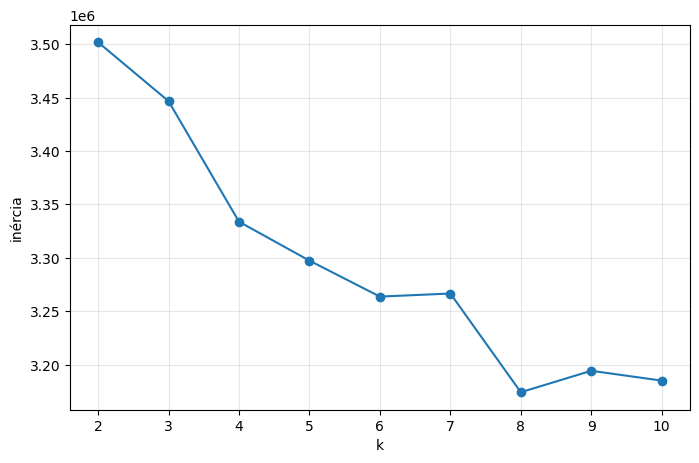

In [18]:
inercia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans.fit(X_cluster_sample)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inercia, marker='o')
plt.xlabel('k')
plt.ylabel('inércia')
plt.xticks(K)
plt.grid(True, alpha=0.3)
plt.show()

Interpretação:

O gráfico mostra uma redução significativa da inércia entre **2 e 4 clusters**, indicando que os primeiros agrupamentos capturam boa parte da estrutura dos dados.

A partir desse ponto, a curva passa a apresentar uma redução mais gradual, sugerindo uma diminuição do benefício obtido ao adicionar novos grupos.

__________
#### **Método 2 - Silhouette Score**

Após a análise inicial utilizando o Método do Cotovelo, foi aplicada uma segunda métrica para avaliar a qualidade dos agrupamentos: o **Silhouette Score**.

O Silhouette Score mede o quanto cada registro está:
- Próximo dos elementos do seu próprio cluster
- Distante dos elementos dos demais clusters

``Quanto maior o valor, melhor a separação entre os grupos``

- Próximo de 1 -> clusters bem definidos e separados.
- Próximo de 0 -> clusters com sobreposição significativa.
- Valores negativos -> indício de agrupamentos inadequados.

In [19]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = kmeans.fit_predict(X_cluster_sample)

    score = silhouette_score(X_cluster_sample, labels)
    silhouette_scores.append(score)

for k, score in zip(K, silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.4f}")

k = 2: Silhouette Score = 0.1844
k = 3: Silhouette Score = 0.4648
k = 4: Silhouette Score = 0.0973
k = 5: Silhouette Score = 0.1857
k = 6: Silhouette Score = 0.1430
k = 7: Silhouette Score = 0.1526
k = 8: Silhouette Score = 0.1335
k = 9: Silhouette Score = 0.0667
k = 10: Silhouette Score = -0.1486


O melhor resultado foi obtido com **K = 3**, alcançando um Silhouette Score de **0,4648**, valor significativamente superior aos demais cenários testados.

______________
#### Avaliação da redução de dimensionalidade com PCA

Após a preparação dos dados, foi realizado um teste com **PCA (Principal Component Analysis)** para avaliar a possibilidade de reduzir a quantidade de variáveis antes da clusterização

PCA transforma as variáveis originais em um conjunto menor de componentes (preservando partes importantes)

Resultado:
- Foi definido que o PCA deveria preservar **90% da variância total dos dados**
- Mesmo preservando apenas 90% da variância, ainda são necessários **169 componentes** para representar adequadamente a estrutura da base
- redução obtida foi relativamente pequena

In [20]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90, random_state=42)  # mantém 90% da variância
X_cluster_pca = pca.fit_transform(X_cluster_scaled)

print(f"Dimensões originais: {X_cluster_scaled.shape[1]}")
print(f"Componentes para explicar 90% da variância: {X_cluster_pca.shape[1]}")

Dimensões originais: 244
Componentes para explicar 90% da variância: 169


_______________
### Definição do modelo final de clusterização

Com base nas análises realizadas anteriormente, foi definido **K = 3** como a quantidade de clusters para o modelo final.

Essa decisão foi baseada principalmente nos resultados do **Silhouette Score**

Resultados:
- **Cluster 0** concentra a maior parte dos chamados da base, representando aproximadamente dois terços dos registros.
- **Cluster 1** possui um volume intermediário e pode representar um perfil operacional distinto do grupo principal.
- **Cluster 2** é o menor dos grupos identificados, indicando um conjunto mais específico de chamados com características próprias.

In [21]:
K_FINAL = 3
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

df_cluster['cluster'].value_counts().sort_index()

cluster
0    77719
1    31494
2    13330
Name: count, dtype: int64

### **O que cada Cluster representa?**

##### Cluster 0 - Chamados gerados por monitoramento
Principais características:
- 77.719 chamados
- 100% dos registros originados por monitoramento
- Maior concentração de chamados de baixa prioridade
- 71% classificados como "4 - Baixa"
- 45% dos registros associados a AM
- Categoria predominante: **INFRA_Monitoramento** (100%)

##### Cluster 1 - Chamados operacionais gerais
Principais características:
- 31.494 chamados
- Distribuição equilibrada entre abertura manual (49%) e monitoramento (51%)
- Predominância de prioridade média (63%)
- Baixa presença de AM (2%)
- Não existe uma única categoria dominante, indicando maior diversidade de assuntos

##### Cluster 2 - Chamados especializados
Principais características:
- 13.330 chamados.
- Predominância de monitoramento (79%)
- Maior participação de chamados de alta prioridade
- 29% classificados como "2 - Alta"
- Forte concentração em categorias específicas:
    - cat71 (53,4%)
    - cat73 (23,9%)
    - cat137 (11,7%)

In [22]:
perfil_numerico = df_cluster.groupby('cluster')[['hora_abertura', 'dia_semana', 'fim_de_semana', 'tem_AM']].mean().round(2)
print("Perfil médio (variáveis numéricas) por cluster:")
print(perfil_numerico)

Perfil médio (variáveis numéricas) por cluster:
         hora_abertura  dia_semana  fim_de_semana  tem_AM
cluster                                                  
0                11.37        2.88           0.26    0.45
1                12.21        2.47           0.14    0.02
2                11.33        2.62           0.20    0.00


In [23]:
print("\nDistribuição de Prioridade por cluster (%):")
print(pd.crosstab(df_cluster['cluster'], df_cluster['Prioridade'], normalize='index').round(2) * 100)


Distribuição de Prioridade por cluster (%):
Prioridade  1 - Crítica  2 - Alta  3 - Média  4 - Baixa  5 - Muito Baixa
cluster                                                                 
0                   0.0       7.0       22.0       71.0              0.0
1                   0.0      20.0       63.0       17.0              0.0
2                   0.0      29.0       39.0       31.0              2.0


In [24]:
print("\nAberto por (Manual vs Monitoramento) por cluster (%):")
print(pd.crosstab(df_cluster['cluster'], df_cluster['Aberto por'], normalize='index').round(2) * 100)


Aberto por (Manual vs Monitoramento) por cluster (%):
Aberto por  Manual  Monitoramento
cluster                          
0              0.0          100.0
1             49.0           51.0
2             21.0           79.0


In [25]:
print("\nTop 3 Categorias por cluster:")
for c in sorted(df_cluster['cluster'].unique()):
    print(f"\nCluster {c} (n={ (df_cluster['cluster'] == c).sum() }):")
    print(df_cluster[df_cluster['cluster'] == c]['Categoria_cluster'].value_counts(normalize=True).head(3).round(3) * 100)


Top 3 Categorias por cluster:

Cluster 0 (n=77719):
Categoria_cluster
INFRA_Monitoramento    100.0
cat77                    0.0
Name: proportion, dtype: float64

Cluster 1 (n=31494):
Categoria_cluster
OUTROS    14.0
cat77     14.0
cat85     13.7
Name: proportion, dtype: float64

Cluster 2 (n=13330):
Categoria_cluster
cat71     53.4
cat73     23.9
cat137    11.7
Name: proportion, dtype: float64
